In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from matplotlib.ticker import FormatStrFormatter
from src.plots import Plots
from src.evaluation import Evaluation
plt.rcParams['axes.grid'] = True

In [2]:
FONTSIZE=14

In [3]:
def plot_demand(scenarios, scenario_labels, name):
    def get_demand(agents, items):
        demands = {i:[] for i in items[0]}
        n_agents = len(agents[0])
        for idx, agent in enumerate(agents):
            for i in demands:
                count = 0
                for pref in agent.values():
                    if pref[0] == i:
                        count += 1
                demands[i].append(count)
        avg_demand = {i:(np.average(demands[i])/n_agents,np.std(demands[i])/n_agents) for i in demands}
        return avg_demand
    fig, ax = plt.subplots(1)
    plt.rcParams.update({'font.size': FONTSIZE})
    for label in scenario_labels:
        not_placed_id = scenarios[label]['Not Placed']
        items_wo_np = {i:c for i,c in scenarios[label]['items'][0].items() if i != not_placed_id}
        d = get_demand(scenarios[label]['agents'], [items_wo_np]*len(scenarios[label]['items']))
        x = sorted([k for k in d.keys()])
        demand = [d[k][0] for k in x]
        demand = sorted(demand, reverse=True)
        if name == 'ams':
            if label == 'havo/vwo':
                label = 'havo'
            label = label.upper()
        ax.plot(x, demand, label=f"{label}", linewidth=2)
        ax.fill_between(x, demand, 0, alpha=0.2)
    ax.set_xlabel("Items", fontsize=FONTSIZE)
    ax.set_ylabel("Share of Demand", fontsize = FONTSIZE)
    plt.legend(fontsize=FONTSIZE)
    plt.tight_layout()
    plt.savefig(f'demand-{name}.png')
    return ax

In [4]:
N_AGENTS = 1000
N_ITEMS = 10
DEFAULT_TOPN = "Mixed-n"
DEFAULT_FRACTION = 1.0
DEFAULT_STRATEGY = "FOH"
synth_scenario_labels = ["Exponential", "Linear", "Logistic"]
ams_scenario_labels = ["vwo", "havo/vwo", "vmbo"]
topns = [1, 2, 3, "Mixed-n"]
fractions = [1.0, .75, .50, .25]

In [5]:
amsdata = pickle.load(open('ams_data_seed_1610_mixed_n.pkl', 'rb'))
synthdata = pickle.load(open('synth_data_seed_1610.pkl', 'rb'))

### Performance Curve

<Axes: xlabel='Items', ylabel='Share of Demand'>

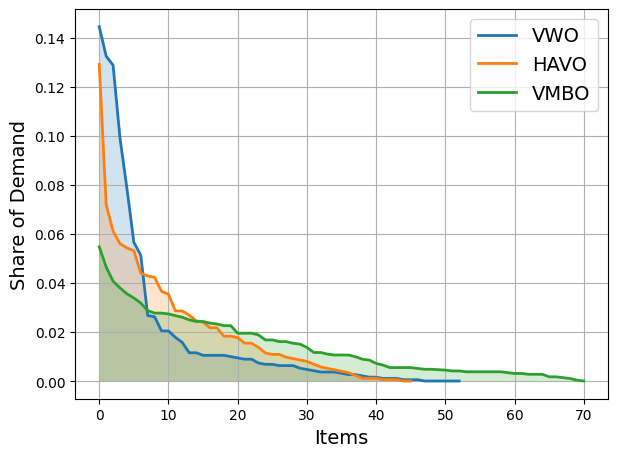

In [6]:
plot_demand(amsdata, ams_scenario_labels, "ams")

<Axes: xlabel='Items', ylabel='Share of Demand'>

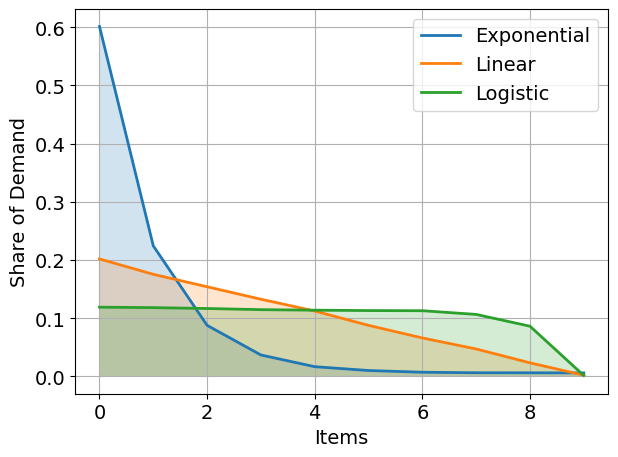

In [7]:
plot_demand(synthdata, synth_scenario_labels, "synth")

In [8]:
ALPHA = 0.1

OrderedDict([(-2, 0.0), (-1, 0.0), (0, 12.249081598226049), (1, 12.26671920278605), (2, 13.359281417800885), (3, 14.586966785456118), (4, 12.51137082817067), (5, 8.81047104302602), (6, 5.67929573098637), (7, 3.6662787673607147), (8, 2.9933259094191533), (9, 1.7145261736118234)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 9.663312061607035), (1, 14.156779294740737), (2, 15.035105586592998), (3, 13.596823158370487), (4, 13.561710806531748), (5, 0.13999999999999999)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 10.996744972945402), (1, 4.406177481672748), (2, 5.61159513863928), (3, 8.430895563343197), (4, 7.523297149521611), (5, 7.577229044974159), (6, 9.013079384982692), (7, 7.864477096412704), (8, 9.068627239003707), (9, 9.526720317087092)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 11.380052723955194), (1, 14.882150382253231), (2, 4.130084744893257), (3, 5.66448585486803), (4, 7.117977240761592), (5, 7.5580156125797995), (6, 8.574753640775926), (7, 7.505304790613104), (8, 8.959218715937233), (9, 7

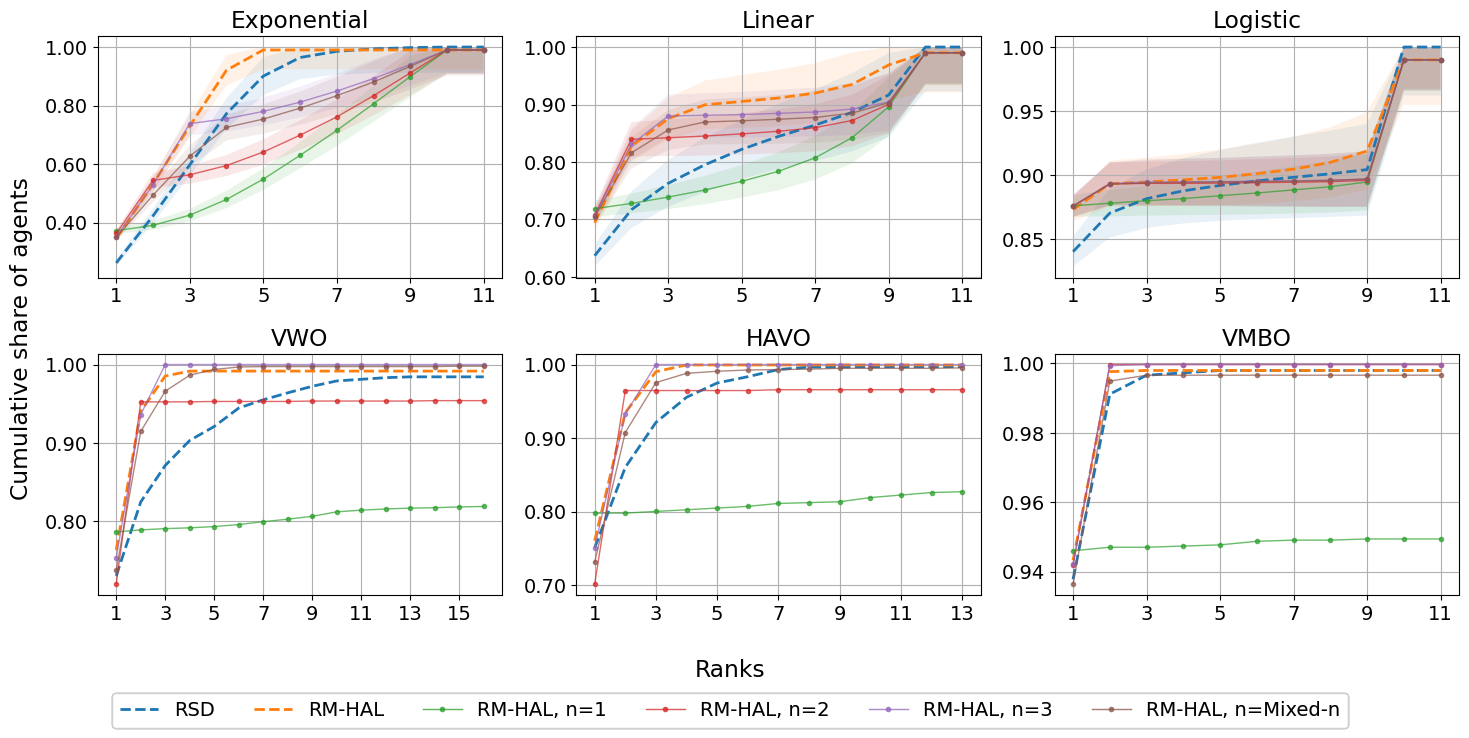

In [9]:
plt.rcParams['axes.grid'] = True
plt.rcParams.update({'font.size': FONTSIZE})
N_COL = 3
N_ROW = 2
fig, ax = plt.subplots(N_ROW,N_COL)
fig.set_figheight(N_ROW * 3.5)
fig.set_figwidth(N_COL * 5)
plotter = Plots()
combined_labels = synth_scenario_labels + ams_scenario_labels
for i,ax in enumerate(fig.axes):
    row = int(i / N_COL)
    col = int(i % N_COL)
    label = combined_labels[i]
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    style = {
        'RSD' : {
            'linestyle': 'dashed',
            'linewidth': 2,
            'alpha': 1
        },
        'RM-HAL': {
            'linestyle': 'dashed',
            'linewidth': 2,
            'alpha': 1
        }
    }
    baselines = ['RSD', 'RM-HAL']
    for i,n in enumerate(topns):
        style[f'RM-HAL, n={n}'] = {'label' : f'n={n}', 'marker':'.', 'linewidth':1, 'alpha':0.7, 'linestyle':'solid'}
    exp_labels = baselines + [f'RM-HAL, n={topn}' for topn in topns]
    slabels = [f'n={n}' for n in topns]
    if row == 0:
        selected_data = synthdata
        ax.set_title(f'{label}')
    else:
        selected_data = amsdata
        t = 'havo' if label == 'havo/vwo' else label
        ax.set_title(f'{t.upper()}')
    _, lines = plotter.average_cumulative_plot([selected_data[label][exp_label] for exp_label in exp_labels], labels=exp_labels, agents=[selected_data[label]['agents']]*len(exp_labels), ax=ax, alpha=ALPHA, cstyle=style)
    dummy, = ax.plot([], marker='None', linestyle='None', label='')
    lb = ['Truthful'] + exp_labels[:2] + ['Strategic'] + slabels[:2] + [''] + slabels[2:]
    lgd = fig.legend(lines, exp_labels, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.07), fontsize=FONTSIZE)
    # ax.set_xlabel('Ranks')
fig.supylabel("Cumulative share of agents")
fig.supxlabel("Ranks")
plt.tight_layout()
plt.savefig(f'fig_performance_n.png', bbox_inches='tight')

OrderedDict([(-2, 0.0), (-1, 0.0), (0, 12.249081598226049), (1, 12.26671920278605), (2, 13.359281417800885), (3, 14.586966785456118), (4, 12.51137082817067), (5, 8.81047104302602), (6, 5.67929573098637), (7, 3.6662787673607147), (8, 2.9933259094191533), (9, 1.7145261736118234)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 9.663312061607035), (1, 14.156779294740737), (2, 15.035105586592998), (3, 13.596823158370487), (4, 13.561710806531748), (5, 0.13999999999999999)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 11.291696063922373), (1, 12.920928759187552), (2, 12.157302332343306), (3, 7.9656512602548695), (4, 5.512204640613408), (5, 6.838976531616408), (6, 6.92288957011449), (7, 7.364346542633636), (8, 7.683983341991314), (9, 8.135944935900193)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 11.248626582832236), (1, 12.310385859102874), (2, 11.704511950525747), (3, 8.907884148326133), (4, 7.430639272633278), (5, 6.455416330493333), (6, 8.182151306349695), (7, 5.3867986782503765), (8, 4.224168557242952), 

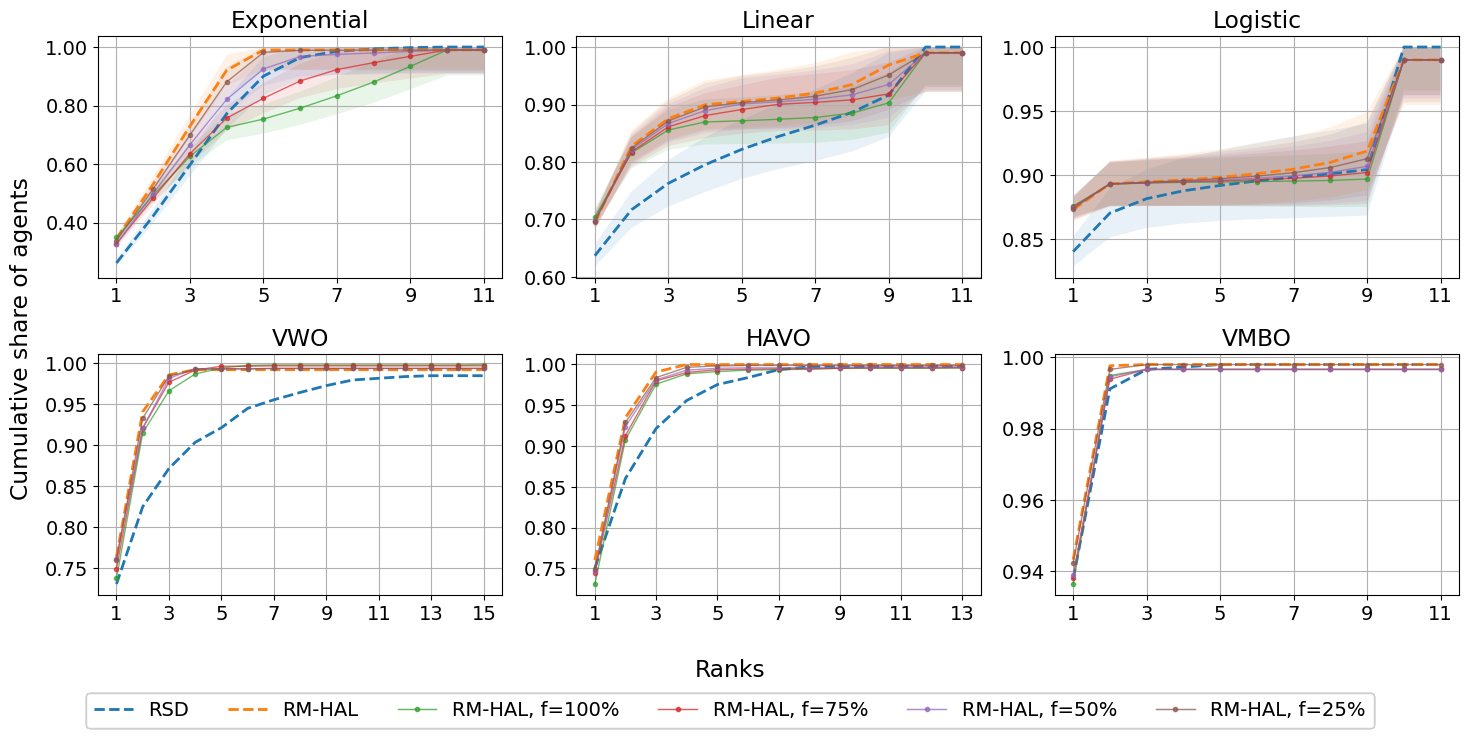

In [10]:
plt.rcParams['axes.grid'] = True
plt.rcParams.update({'font.size': FONTSIZE})
N_COL = 3
N_ROW = 2
fig, ax = plt.subplots(N_ROW,N_COL)
fig.set_figheight(N_ROW * 3.5)
fig.set_figwidth(N_COL * 5)
plotter = Plots()
combined_labels = synth_scenario_labels + ams_scenario_labels
for i,ax in enumerate(fig.axes):
    row = int(i / N_COL)
    col = int(i % N_COL)
    label = combined_labels[i]
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    style = {
        'RSD' : {
            'linestyle': 'dashed',
            'linewidth': 2,
            'alpha': 1
        },
        'RM-HAL': {
            'linestyle': 'dashed',
            'linewidth': 2,
            'alpha': 1
        }
    }
    baselines = ['RSD', 'RM-HAL']
    ax.set_title(f'{label}')
    for i,fraction in enumerate(fractions):
        style[f'RM-HAL, f={int(fraction*100)}%'] = {'label' : f'f={int(fraction*100)}%', 'marker':'.', 'linewidth':1, 'alpha':0.7, 'linestyle':'solid'}
    exp_labels = baselines + [f'RM-HAL, f={int(fraction*100)}%' for fraction in fractions]
    slabels = [f'f={int(fraction*100)}%' for fraction in fractions]
    if row == 0:
        selected_data = synthdata
        ax.set_title(f'{label}')
    else:
        selected_data = amsdata
        t = 'havo' if label == 'havo/vwo' else label
        ax.set_title(f'{t.upper()}')
    _, lines = plotter.average_cumulative_plot([selected_data[label][exp_label] for exp_label in exp_labels], labels=exp_labels, agents=[selected_data[label]['agents']]*len(exp_labels), ax=ax, alpha=ALPHA, cstyle=style)
    dummy, = ax.plot([], marker='None', linestyle='None', label='')
    lb = ['Truthful'] + exp_labels[:2] + ['Strategic'] + slabels[:2] + [''] + slabels[2:]
    lgd = fig.legend(lines, exp_labels, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.07), fontsize=FONTSIZE)
    # ax.set_xlabel('Ranks')
fig.supylabel("Cumulative share of agents")
fig.supxlabel("Ranks")
plt.tight_layout()
plt.savefig(f'fig_performance_f.png', bbox_inches='tight')

OrderedDict([(-2, 0.0), (-1, 1.1029052543169788), (0, 10.652023281987324), (1, 8.262905058149949), (2, 9.782617236711246), (3, 8.519248793174196), (4, 10.397615111168523), (5, 9.357884376289332), (6, 2.4248711305964283), (7, 0.27999999999999997)])
OrderedDict([(-2, 0.0), (-1, 1.102905254316979), (0, 8.371977066380436), (1, 10.605300561511683), (2, 6.845991527894261), (3, 5.70350769263968), (4, 2.3627103080995773), (5, 2.628763968103641), (6, 2.6939933184772378), (7, 2.7684652788142388), (8, 2.8071337695236402), (9, 3.5777087639996634)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 11.863035024815531), (1, 12.706911505161276), (2, 11.942127113709684), (3, 10.711657201385789), (4, 11.025425161870176), (5, 9.31495571648089), (6, 3.2621465325763648), (7, 2.744084546802449), (8, 2.8071337695236402), (9, 3.5777087639996634)])
OrderedDict([(-2, 0.0), (-1, 1.9960961900670018), (0, 17.77926882636066), (1, 8.471717653463198), (2, 6.632164051046988), (3, 4.591688142720496), (4, 5.426748566130551), (5, 

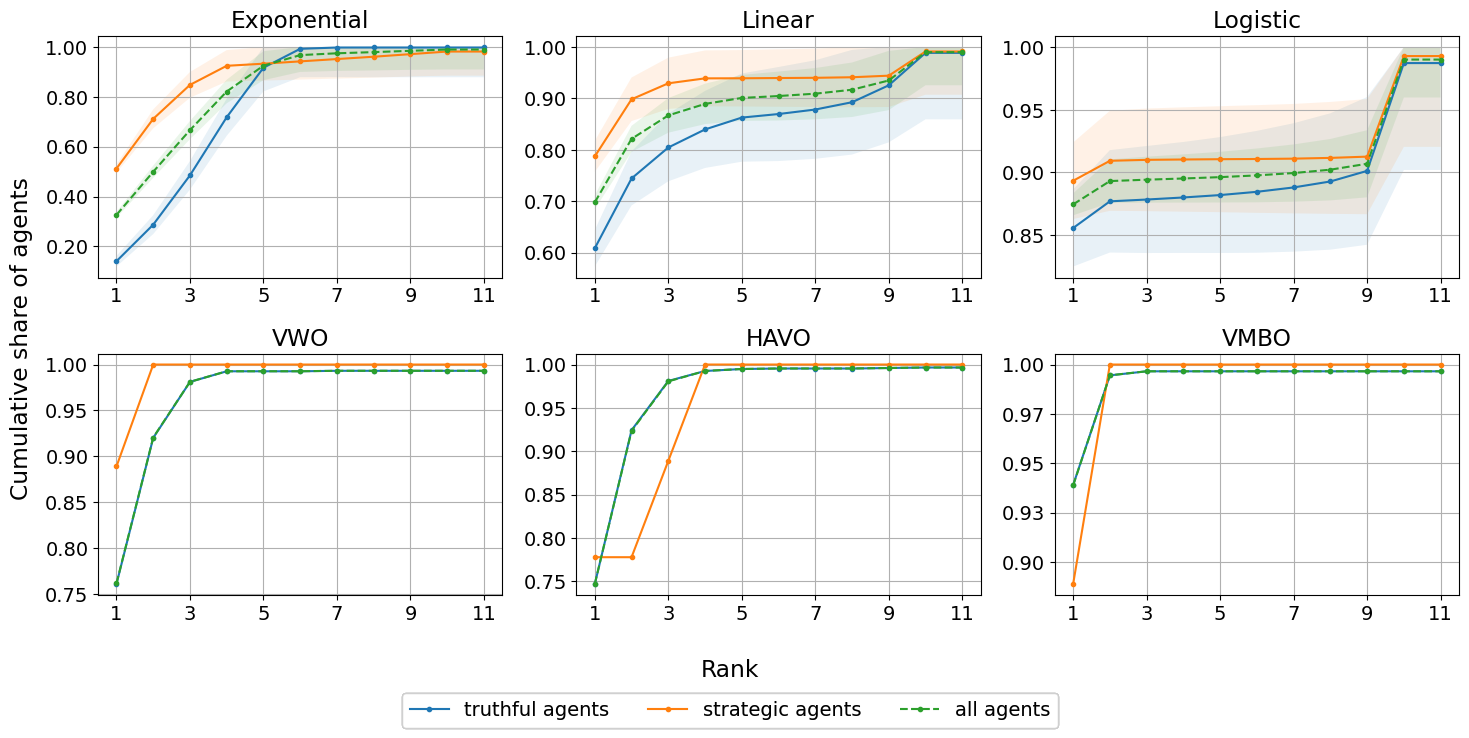

In [23]:
N_COL = 3
N_ROW = 2
fig, ax = plt.subplots(N_ROW,N_COL)
plt.rcParams['axes.grid'] = True
fig.set_figheight(N_ROW * 3.5)
fig.set_figwidth(N_COL * 5)
style = {}
combined_labels = synth_scenario_labels + ams_scenario_labels
topn = 'Mixed-n'
for i,ax in enumerate(fig.axes):
    row = int(i / N_COL)
    col = int(i % N_COL)
    label = (combined_labels*4)[i]
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    exp_labels = [f'RM-HAL, n={topn} truthful', f'RM-HAL, n={topn} strategic', f'RM-HAL, n={topn} baseline']
    style[f'RM-HAL, n={topn} truthful'] =  {'label' : 'truthful', 'marker':'.'}
    style[f'RM-HAL, n={topn} strategic'] =  {'label' : 'strategic', 'marker':'.'}
    style[f'RM-HAL, n={topn} baseline'] =  {'label' : 'all agents', 'linestyle' : 'dashed', 'marker':'.'}
    if row == 0:
        selected_data = synthdata
        ax.set_title(f'{label}')
    else:
        selected_data = amsdata
        t = 'havo' if label == 'havo/vwo' else label
        ax.set_title(f'{t.upper()}')
    _, lines = plotter.average_cumulative_plot([selected_data[label][exp_label] for exp_label in exp_labels], labels=exp_labels, agents=[selected_data[label]['agents']]*len(exp_labels),ax=ax,alpha=ALPHA, cstyle=style, dynamic_ylim=False)
    legend_labels = ['truthful agents', 'strategic agents', 'all agents']
    lgd = fig.legend(lines, legend_labels, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.07), fontsize=FONTSIZE)
fig.supxlabel("Rank")
fig.supylabel("Cumulative share of agents")
plt.tight_layout()
plt.savefig(f'fig_individual_n={topn}.png', bbox_inches='tight')

# PR Plot

OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 0.0), (7, 0.0), (8, 0.0), (9, 0.0), (10, 0.0), (11, 0.0), (12, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 0.0), (7, 0.0), (8, 0.0), (9, 0.0), (10, 0.0), (11, 0.0), (12, 0.0), (13, 0.0), (14, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 0.0), (7, 0.0), (8, 0.0), (9, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 0.0), (7, 0.0), (8, 0.0), (9, 0.0), (10, 0.0), (11, 0.0), (12, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.

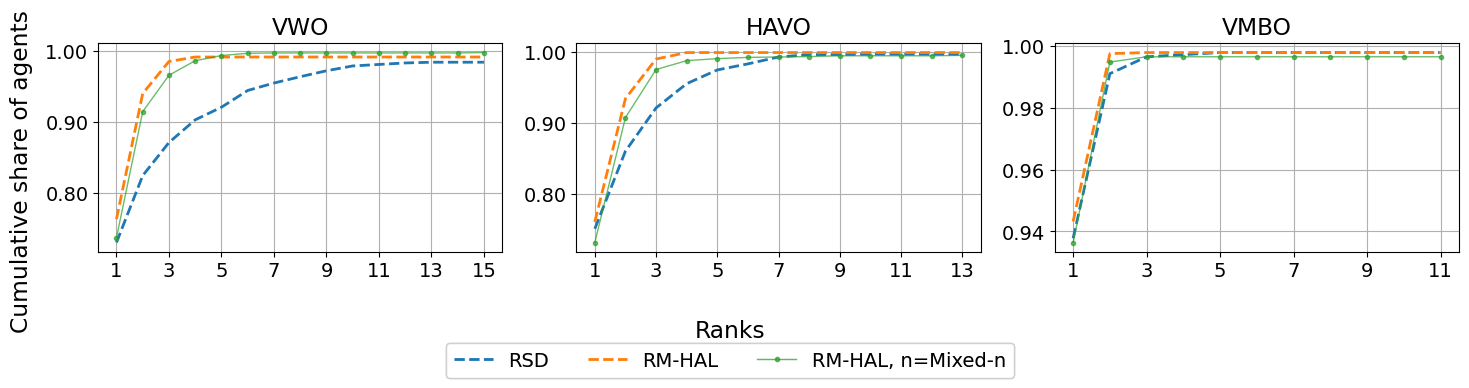

In [26]:
plt.rcParams['axes.grid'] = True
plt.rcParams.update({'font.size': FONTSIZE})
N_COL = 3
N_ROW = 1
fig, ax = plt.subplots(N_ROW,N_COL)
fig.set_figheight(N_ROW * 3.5)
fig.set_figwidth(N_COL * 5)
plotter = Plots()
combined_labels = ams_scenario_labels
for i,ax in enumerate(fig.axes):
    row = int(i / N_COL)
    col = int(i % N_COL)
    label = combined_labels[i]
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    style = {
        'RSD' : {
            'linestyle': 'dashed',
            'linewidth': 2,
            'alpha': 1
        },
        'RM-HAL': {
            'linestyle': 'dashed',
            'linewidth': 2,
            'alpha': 1
        }
    }
    baselines = ['RSD', 'RM-HAL']
    for i,n in enumerate(topns):
        style[f'RM-HAL, n={n}'] = {'label' : f'n={n}', 'marker':'.', 'linewidth':1, 'alpha':0.7, 'linestyle':'solid'}
    top_n_selected = ['Mixed-n']
    exp_labels = baselines + [f'RM-HAL, n={topn}' for topn in top_n_selected]
    slabels = [f'n={n}' for n in topns]

    selected_data = amsdata
    t = 'havo' if label == 'havo/vwo' else label
    ax.set_title(f'{t.upper()}')
    _, lines = plotter.average_cumulative_plot([selected_data[label][exp_label] for exp_label in exp_labels], labels=exp_labels, agents=[selected_data[label]['agents']]*len(exp_labels), ax=ax, alpha=ALPHA, cstyle=style)
    dummy, = ax.plot([], marker='None', linestyle='None', label='')
    lb = ['Truthful'] + exp_labels[:2] + ['Strategic'] + slabels[:2] + [''] + slabels[2:]
    lgd = fig.legend(lines, exp_labels, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.12), fontsize=FONTSIZE)
    # ax.set_xlabel('Ranks')
fig.supylabel("Cumulative share of agents")
fig.supxlabel("Ranks")
plt.tight_layout()
plt.savefig(f'pr_plot_rsd_rm_mixed.png', bbox_inches='tight')

In [13]:
for label in ams_scenario_labels:
    for i in range(50):
        mixed_n_map = amsdata[label]['agents, n=Mixed-n'][i][1]
        mixed_n_alloc = amsdata[label]['RM-HAL, n=Mixed-n'][i]
        agents = amsdata[label]['agents'][i]
        for topn in range(1,6):
            mixed_n_alloc_separated = {k:v for k,v in mixed_n_alloc.items() if k in mixed_n_map[topn]}
            mixed_n_alloc_agents = {k:v for k,v in agents.items() if k in mixed_n_map[topn]}
            if f'Mixed-n alloc {topn}' not in amsdata[label]:
                amsdata[label][f'Mixed-n alloc {topn}'] = []
            if f'Mixed-n agents {topn}' not in amsdata[label]:
                amsdata[label][f'Mixed-n agents {topn}'] = []
            amsdata[label][f'Mixed-n alloc {topn}'].append(mixed_n_alloc_separated)
            amsdata[label][f'Mixed-n agents {topn}'].append(mixed_n_alloc_agents)

OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 0.0), (7, 0.0), (8, 0.0), (9, 0.0), (10, 0.0), (11, 0.0), (12, 0.0), (13, 0.0), (14, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 0.0), (7, 0.0), (8, 0.0), (9, 0.0), (10, 0.0), (11, 0.0), (12, 0.0), (13, 0.0), (14, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 0.0), (7, 0.0), (8, 0.0), (9, 0.0), (10, 0.0), (11, 0.0), (12, 0.0)])
OrderedDict([(-2, 0.0), (-1, 0.0), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0), (5, 0.0), (6, 0.0), (7, 0.0), (8, 0.0), (9, 0.0), (10, 0.0), (11, 0.0), (12, 0.0

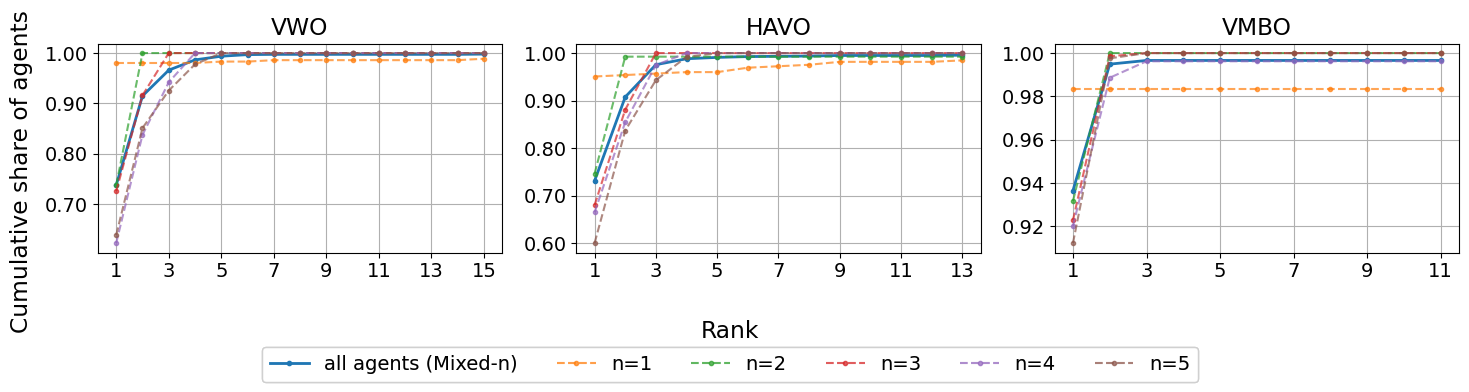

In [27]:
N_COL = 3
N_ROW = 1
fig, ax = plt.subplots(N_ROW,N_COL)
plt.rcParams['axes.grid'] = True
fig.set_figheight(N_ROW * 3.5)
fig.set_figwidth(N_COL * 5)
style = {}
combined_labels = ams_scenario_labels
topn = 3
for i,ax in enumerate(fig.axes):
    row = int(i / N_COL)
    col = int(i % N_COL)
    label = combined_labels[i]
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    exp_labels = ['RM-HAL, n=Mixed-n'] + [f'Mixed-n alloc {topn}' for topn in range(1,6)]
    style['RM-HAL, n=Mixed-n'] =  {'label' : 'all agents', 'marker':'.', 'linewidth':2}
    for topn in range(1,6):
        style[f'Mixed-n alloc {topn}'] =  {'label' : f'n={topn}', 'marker':'.', 'linestyle' : 'dashed','alpha':0.7}
    selected_data = amsdata
    t = 'havo' if label == 'havo/vwo' else label
    ax.set_title(f'{t.upper()}')
    _, lines = plotter.average_cumulative_plot([selected_data[label][exp_label] for exp_label in exp_labels], labels=exp_labels, agents=[selected_data[label]['agents']]*len(exp_labels),ax=ax,alpha=ALPHA, cstyle=style, dynamic_ylim=False)
    legend_labels = ['all agents (Mixed-n)'] + [f'n={topn}' for topn in range(1,6)]
    lgd = fig.legend(lines, legend_labels, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.13), fontsize=FONTSIZE)
fig.supxlabel("Rank")
fig.supylabel("Cumulative share of agents")
plt.tight_layout()
plt.savefig(f'pr_plot_mixed_n_split.png', bbox_inches='tight')

In [20]:
# amsdata = pickle.load(open('data/ams_data_no_cutoff.pkl', 'rb'))
# synthdata = pickle.load(open('data/synth_data_no_cutoff.pkl', 'rb'))
# ams_scenario_labels = ["vwo"]
# synth_scenario_labels = ["Exponential"]

In [13]:
# N_COL = 2
# N_ROW = 1
# fig, ax = plt.subplots(N_ROW,N_COL)
# plt.rcParams['axes.grid'] = True
# fig.set_figheight(N_ROW * 4)
# fig.set_figwidth(N_COL * 5.5)
# evaluation = Evaluation()
# style = {}
# for i,ax in enumerate(fig.axes):
#     if i==1:
#         scenarios = synthdata
#         scenario_labels = synth_scenario_labels
#     else:
#         scenarios = amsdata
#         scenario_labels = ams_scenario_labels
#     topn = 1
#     label = scenario_labels[0]
#     ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
#     ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
#     exp_labels = [f'RM-HAL, n={topn}', f'RM-HAL, n={topn}']
#     ax.set_title(label)
#     stratetic_prefs = [sa for sa, _ in scenarios[label][f'agents, n={topn}']]
#     plotter.average_cumulative_plot([scenarios[label][exp_label] for exp_label in exp_labels], labels=exp_labels, agents=[scenarios[label]['agents'], stratetic_prefs],ax=ax,alpha=0.7, dynamic_ylim=False)
#     ax.legend(loc='lower right',fancybox=False, shadow=False, title=f'RM-HAL, n={topn}')
#
# fig.supxlabel("Rank")
# fig.supylabel("Cumulative share of agents")
# plt.tight_layout()

In [16]:
selected_market = ams_scenario_labels
selected_data = amsdata
evaluation = Evaluation()

t = evaluation.get_table_header()

for market in selected_market:
    exp_labels = ['RSD', 'RM-HAL'] + [f'RM-HAL, n={topn}' for topn in topns]
    matches = [selected_data[market][exp_label] for exp_label in exp_labels]
    agents = [selected_data[market]['agents'] for _ in exp_labels]
    for i, label in enumerate(exp_labels):
        row = evaluation.add_logs(f'{market}', f'{label}', matches[i], agents[i])
        t.add_row(row)
print(t)

|  Market  |       Method      | Top-1 | Top-3  | Top-5  | Rank 6+ | Not Placed | Placed Elsewhere | Max Rank | Avg Rank |
|:--------:|:-----------------:|:-----:|:------:|:------:|:-------:|:----------:|:----------------:|:--------:|:--------:|
|   vwo    |        RSD        | 73.05 | 87.13  | 92.10  |   6.33  |    1.57    |       0.00       |   16.0   |   0.91   |
|   vwo    |       RM-HAL      | 76.35 | 98.53  | 99.16  |   0.00  |    0.84    |       0.00       |   3.0    |   0.30   |
|   vwo    |    RM-HAL, n=1    | 78.65 | 79.07  | 79.33  |   2.56  |    0.00    |      18.11       |   25.0   |   2.40   |
|   vwo    |    RM-HAL, n=2    | 72.00 | 95.24  | 95.29  |   0.10  |    0.00    |       4.60       |   19.0   |   0.80   |
|   vwo    |    RM-HAL, n=3    | 75.35 | 100.00 | 100.00 |   0.00  |    0.00    |       0.00       |   2.0    |   0.31   |
|   vwo    | RM-HAL, n=Mixed-n | 73.73 | 96.60  | 99.37  |   0.42  |    0.00    |       0.21       |   14.0   |   0.41   |
| havo/vwo |    

In [15]:
t = evaluation.get_table_header()

selected_market = ams_scenario_labels
selected_data = amsdata

for market in selected_market:
    exp_labels = ['RSD', 'RM-HAL'] + [f'RM-HAL, f={int(fraction*100)}%' for fraction in fractions]
    matches = [selected_data[market][exp_label] for exp_label in exp_labels]
    agents = [selected_data[market]['agents'] for _ in exp_labels]
    for i, label in enumerate(exp_labels):
        row = evaluation.add_logs(f'{market}', f'{label}', matches[i], agents[i])
        t.add_row(row)
print(t)

|  Market  |     Method     | Top-1 | Top-3 | Top-5 | Rank 6+ | Not Placed | Placed Elsewhere | Max Rank | Avg Rank |
|:--------:|:--------------:|:-----:|:-----:|:-----:|:-------:|:----------:|:----------------:|:--------:|:--------:|
|   vwo    |      RSD       | 73.05 | 87.13 | 92.10 |   6.33  |    1.57    |       0.00       |   16.0   |   0.91   |
|   vwo    |     RM-HAL     | 76.35 | 98.53 | 99.16 |   0.00  |    0.84    |       0.00       |   3.0    |   0.30   |
|   vwo    | RM-HAL, f=100% | 73.73 | 96.60 | 99.37 |   0.42  |    0.00    |       0.21       |   14.0   |   0.41   |
|   vwo    | RM-HAL, f=75%  | 74.93 | 97.65 | 99.58 |   0.05  |    0.21    |       0.16       |   14.0   |   0.37   |
|   vwo    | RM-HAL, f=50%  | 76.14 | 98.12 | 99.27 |   0.05  |    0.58    |       0.10       |   12.0   |   0.33   |
|   vwo    | RM-HAL, f=25%  | 76.03 | 98.38 | 99.27 |   0.05  |    0.68    |       0.00       |   6.0    |   0.31   |
| havo/vwo |      RSD       | 75.04 | 92.12 | 97.49 |   

In [12]:
from src.data import SchoolChoiceData
import pandas as pd
YEAR = 2017
path_to_data = f"../../data/osvo/da_stb/v1/{YEAR}.xlsx"
loader = SchoolChoiceData(path=path_to_data)
school_df, student_df = loader.load_dataframes()

# filter out priority students
priority = student_df[student_df['Voorrang/Hardheid eerste voorkeur'] != '-']
priority = priority[priority['Voorkeur 1'] == priority['Geplaatst op']]
without_priority = pd.concat([student_df, priority]).drop_duplicates(keep=False)
# update capacities
for school in priority['Geplaatst op'].tolist():
    school_df.loc[school_df[school_df['Key'] == school].index, 'Maximale capaciteit definitieve matching'] -= 1
loader.set_dataframes(without_priority, school_df)

In [13]:
agents, items, _, rsm_vwo = loader.load_preferences_capacities(advies='vwo')
agents, items, _, rsm_havo = loader.load_preferences_capacities(advies='havo/vwo')
agents, items, _, rsm_vmbo = loader.load_preferences_capacities(advies='vmbo')

In [14]:
set_vwo = set(rsm_vwo.values())
set_havo = set(rsm_havo.values())
set_vmbo = set(rsm_vmbo.values())

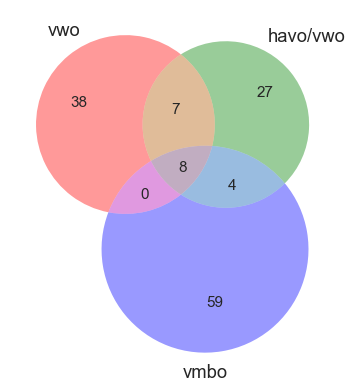

In [15]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn2
venn3([set_vwo, set_havo, set_vmbo], ('vwo', 'havo/vwo', 'vmbo'))
plt.show()

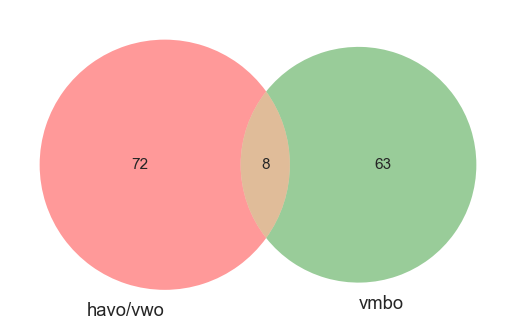

In [54]:
set_vwo_havo = set_vwo.union(set_havo)
venn2([set_vwo_havo, set_vmbo], ('havo/vwo', 'vmbo'))
plt.show()

<Axes: >

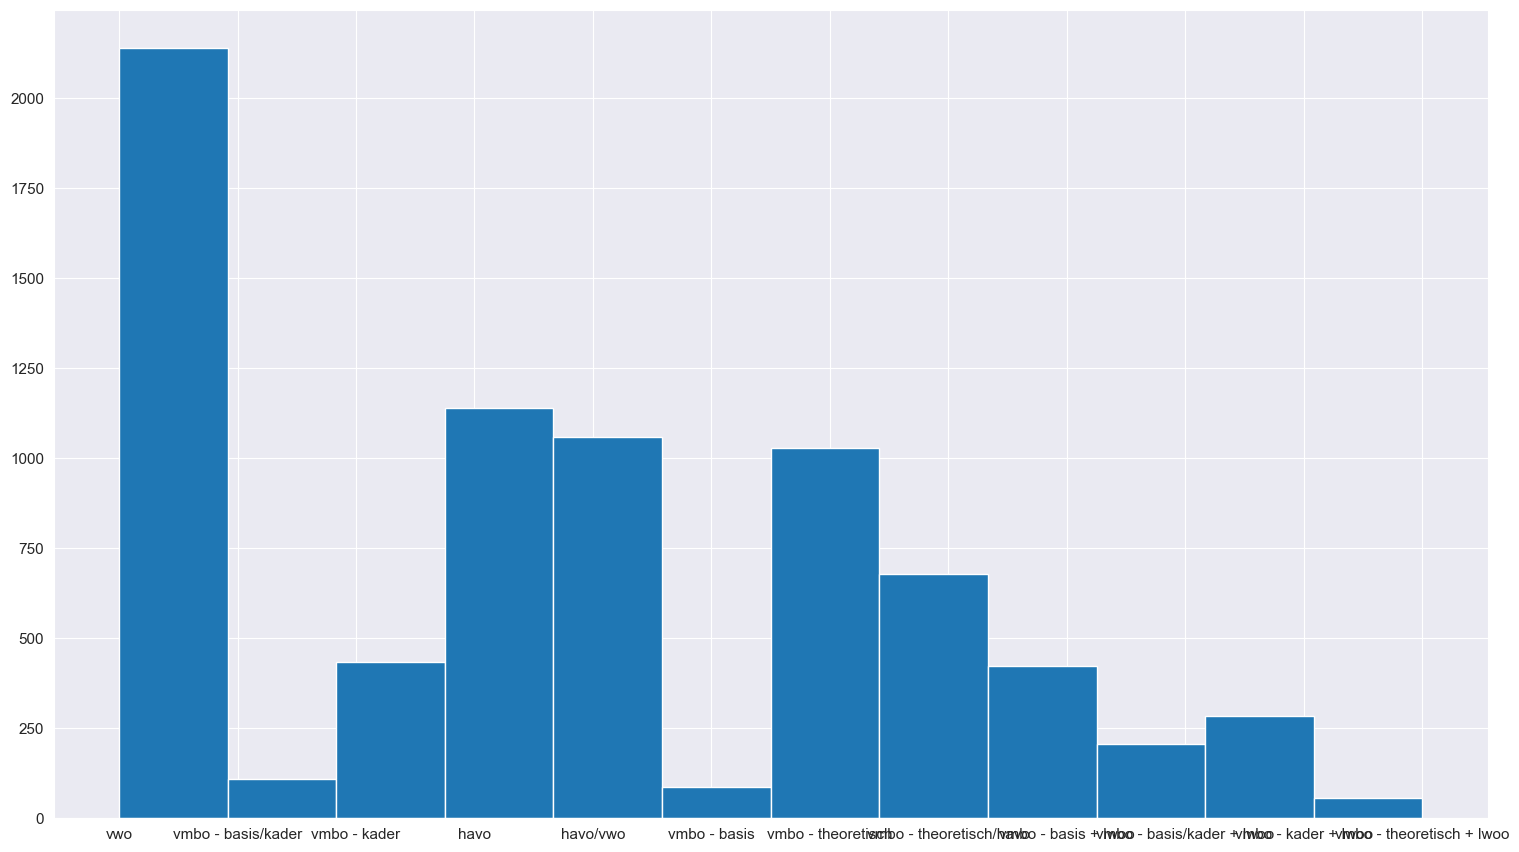

In [58]:
plt.gcf().set_size_inches(18.5, 10.5)
student_df['Advies'].hist(bins=len(student_df['Advies'].unique()))

In [59]:
student_df['Advies'].unique()

array(['vwo', 'vmbo - basis/kader', 'vmbo - kader', 'havo', 'havo/vwo',
       'vmbo - basis', 'vmbo - theoretisch', 'vmbo - theoretisch/havo',
       'vmbo - basis + lwoo', 'vmbo - basis/kader + lwoo',
       'vmbo - kader + lwoo', 'vmbo - theoretisch + lwoo'], dtype=object)

In [60]:
school_df['Capaciteitsgroep'].unique()

array(['vmbo-t, vmbo-t/havo', 'havo, havo/vwo', 'vwo', 'vmbo-k ±lwoo',
       'vmbo-b, vmbo-b/k ± lwoo', 'vmbo-b, vmbo-b/k', 'vmbo-k',
       'havo, havo/vwo, vwo', 'vmbo-t ±lwoo, vmbo-t/havo, havo',
       'vmbo-t±lwoo, vmbo-t/havo, havo',
       'vmbo-b, vmbo-b/k, vmbo-k, vmbo-t ±lwoo, vmbo-t/havo',
       'vmbo-b, vmbo-b/k, vmbo-k ±lwoo',
       'vmbo-k, vmbo-t, vmbo-t/havo, havo, havo/vwo vwo', 'vmbo-t ±lwoo',
       'vmbo-b, vmbo-b/k, vmbo-k, vmbo-t ±lwoo vmbo-t/havo',
       'vmbo-t ± lwoo, vmbo-t/havo',
       'vmbo-t, vmbo-t/havo, havo, havo/vwo, vwo',
       'vmbo-b, vmbo-b/k, vmbo-k, vmbo-t ±lwoo', 'vmbo-b, vmbo-b/k ±lwoo',
       'vmbo-t ±lwoo, vmbo-t/havo, havo, havo/vwo, vwo',
       'vmbo-t ±lwoo, vmbo-t/havo'], dtype=object)